In [ ]:
# env is ambient_doublet
# with R magic

In [11]:
import scanpy as sc
import pandas as pd
import numpy as np

In [2]:
import logging

import anndata2ri
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.rinterface_lib.callbacks
import rpy2.robjects as ro

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

In [ ]:
# redirect R output to python jupyter console
rpy2.rinterface_lib.callbacks.logger.setLevel(logging.INFO)
rpy2.rinterface_lib.callbacks.consolewrite_print = lambda x: print(x, end="")
rpy2.rinterface_lib.callbacks.consolewrite_warnerror = lambda x: print(x, end="")

In [ ]:
%%R
library(Seurat)
library(scater)
library(scDblFinder)
library(BiocParallel)

In [ ]:
%%R
print(sessionInfo())

In [ ]:
np.random.seed(42)

In [17]:
sc.settings.set_figure_params(figsize=(10, 10), facecolor="white")

In [ ]:
adata = sc.read_h5ad(
    "../adata/IBD_preprocessing_after_qc.h5ad"
)
adata

AnnData object with n_obs × n_vars = 198583 × 38606
    obs: 'sample', 'GC_Sample_Number', 'Gender', 'Date_of_surgery', 'Location', 'Disease', 'Segment', 'Age', 'Cells_prefix', 'Condition', 'Disease_segment', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'outlier', 'outlier_colors', 'mt_outlier', 'mt_outlier_colors', 'leiden', 'cell_type'
    var: 'gene_ids', 'feature_types', 'genome', 'gene_names', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'cell_type_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'mt_outlier_colors_colors', 'neighbors', 'outlier_colors_colors', 'pca', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    l

In [7]:
# sanity check
display("Max in adata.X:  ", adata.X.max())
display("Max in layer counts:  ", adata.layers["counts"].max())
display("Max in layer soupx counts:  ", adata.layers["soupX_counts"].max())

'Max in adata.X:  '

8.42060505647168

'Max in layer counts:  '

71831.0

'Max in layer soupx counts:  '

71817.0

In [ ]:
adata.X = adata.layers['soupX_counts'].copy()
# scDbFinder works on counts

In [9]:
# sanity check
display("Max in adata.X:  ", adata.X.max())
display("Max in layer counts:  ", adata.layers["counts"].max())
display("Max in layer soupx counts:  ", adata.layers["soupX_counts"].max())

'Max in adata.X:  '

71817.0

'Max in layer counts:  '

71831.0

'Max in layer soupx counts:  '

71817.0

In [10]:
data_mat = adata.X.T
obs = adata.obs

In [ ]:
# i have choosen to dedoublet based on leiden clustering

In [ ]:
%%R -i data_mat -i obs -o doublet_score -o doublet_class

sc <- SingleCellExperiment(
        list(counts=data_mat),
        colData = obs
        )

bp <- MulticoreParam(30, RNGseed=42)
sce = scDblFinder(sc, clusters="leiden", samples="sample", BPPARAM=bp)

doublet_score = sce$scDblFinder.score
doublet_class = sce$scDblFinder.class

In [ ]:
%%R

print(sce@colData)


In [15]:
adata.obs["scDblFinder_score"] = doublet_score 
adata.obs["scDblFinder_class"] = doublet_class
adata.obs.scDblFinder_class.value_counts()

scDblFinder_class
singlet    183391
doublet     15192
Name: count, dtype: int64

In [23]:
display(adata.obs.dtypes)

sample                        category
GC_Sample_Number              category
Gender                        category
Date_of_surgery               category
Location                      category
Disease                       category
Segment                       category
Age                              int64
Cells_prefix                  category
Condition                     category
Disease_segment               category
n_genes_by_counts                int32
log1p_n_genes_by_counts        float64
total_counts                   float64
log1p_total_counts             float64
pct_counts_in_top_20_genes     float64
total_counts_mt                float64
log1p_total_counts_mt          float64
pct_counts_mt                  float64
outlier                           bool
outlier_colors                category
mt_outlier                        bool
mt_outlier_colors             category
leiden                        category
cell_type                     category
scDblFinder_score        

In [ ]:
sc.pl.umap(adata, color=["scDblFinder_class"], size = 8)

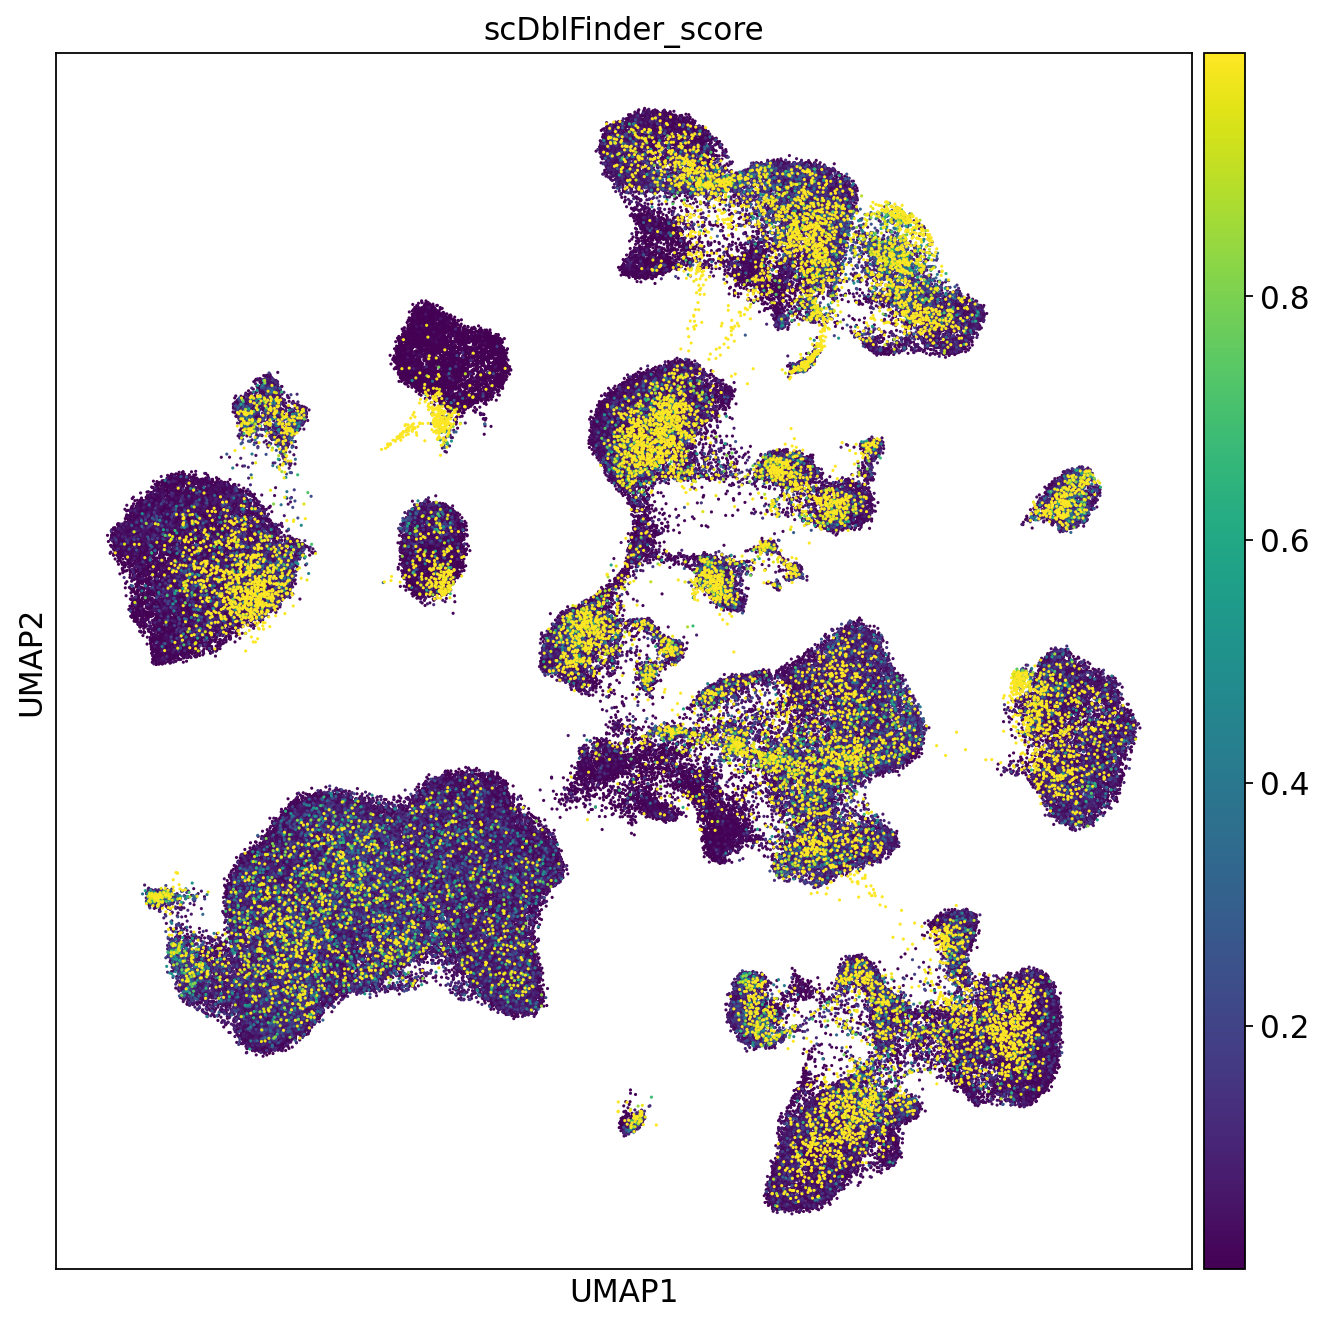

In [19]:
sc.pl.umap(adata, color=["scDblFinder_score"], size = 8)

In [ ]:
sc.pl.scatter(adata, x='log1p_total_counts', y='n_genes_by_counts', color='scDblFinder_score')

In [25]:
adata.obs["scDblFinder_class"] = adata.obs["scDblFinder_class"].astype(str)
adata.obs["scDblFinder_class"] = pd.Categorical(adata.obs["scDblFinder_class"])

In [48]:
print(f"Total number of cells: {adata.n_obs}")
adata = adata[adata.obs["scDblFinder_class"] == "singlet"].copy()

print(f"Number of cells after filtering out doublets: {adata.n_obs}")

Total number of cells: 198583
Number of cells after filtering out doublets: 183391


In [ ]:
adata.write("../adata/IBD_preprocessing_dedoublet.h5ad")